# Rebuilding the Reference MMMs with the Experimental API

In this notebook we rebuild two familiar models with the **experimental** media mix modeling API in `pymc_marketing.mmm.experimental`:

1. The single-market model from the [MMM Example](https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_example.html) notebook.
2. The two-geo hierarchical model from the [MMM Multidimensional Example](https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_multidimensional_example.html) notebook.

The goal is not a new analysis but a translation. For each model we copy the data generating process of the original notebook as it is, write the same model with the experimental API, verify numerically that it is exactly the same probabilistic model that the stable `MMM` class builds, and then fit it and forecast with it. We concentrate on the model: for the business context, the exploratory analysis and the complete set of diagnostics and plots, please refer to the original notebooks.

> **Warning:** The experimental API is under active development and its interfaces may change. It lives in its own namespace and does not modify the stable `MMM` class.

## How the Experimental API Describes a Model

The stable `MMM` class is configured through column names and a `model_config` dictionary, and it assembles a fixed model structure for us: it scales the data, adds a `channel` dimension to the media priors, sums the channel contributions and attaches the likelihood. The experimental API instead asks us to write the model equation from small, composable building blocks:

| Stable `MMM` | Experimental API |
|---|---|
| A data frame plus `date_column`, `channel_columns`, `control_columns` and `target_column` | One `xarray.Dataset` whose variables keep their own labeled dimensions |
| `adstock=...` and `saturation=...` | `Data("spend") >> adstock >> saturation`, applied left to right along `date` |
| `control_columns` with `model_config["gamma_control"]` | `Dot(var_name="controls", prior=...)` |
| `yearly_seasonality=2` with `model_config["gamma_fourier"]` | `Seasonality(YearlyFourier(n_order=2, prior=...))` |
| `model_config["intercept"]` | `Intercept(name, prior=...)` |
| `target_column` with `model_config["likelihood"]` | `Equation(observed="sales", mu=..., likelihood=...)` |
| `dims=("geo",)` | The dimensions of the data variables and of each prior |
| Internal max scaling (`scaling=...`) | Scaling done by us, before the data enter the model |

The guiding principle is that little is implicit: there is no hidden scaling and nothing is summed automatically. The one convenience matches the stable class: a media prior without `dims` follows the dimensions of the spend it transforms, while declared `dims` are kept exactly. We will meet each of these points below, and each one is precisely where the translation needs some care.

## Prepare Notebook

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from pymc_extras.printing import model_table
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation, YearlyFourier
from pymc_marketing.mmm.experimental import MMM, Data, Equation, Seasonality
from pymc_marketing.mmm.mmm import MMM as StableMMM
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation
from pymc_marketing.paths import data_dir
from pymc_marketing.special_priors import LaplacePrior, LogNormalPrior
from pymc_marketing.terms import Dot, Intercept

warnings.filterwarnings("ignore", category=FutureWarning)
# Predictive sampling of the truncated likelihood in Part II runs in Numba object mode.
warnings.filterwarnings("ignore", message="Numba will use object mode")

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

Throughout the notebook we will compare our models against the stable `MMM` class. The helper below evaluates the joint log density (all priors plus the likelihood) of two PyMC models at the same random parameter values. Two models that agree at every point are the same probabilistic model, whatever code was used to build them.

In [2]:
def compare_log_densities(model, reference, n_points=5, seed=0):
    """Evaluate the joint log density of two models at the same random points."""
    point_rng = np.random.default_rng(seed)
    logp, reference_logp = model.compile_logp(), reference.compile_logp()
    start = reference.initial_point()
    rows = []
    for _ in range(n_points):
        point = {
            name: value + point_rng.normal(scale=0.5, size=np.shape(value))
            for name, value in start.items()
        }
        rows.append(
            {"experimental": float(logp(point)), "stable": float(reference_logp(point))}
        )
    comparison = pd.DataFrame(rows)
    np.testing.assert_allclose(
        comparison["experimental"], comparison["stable"], rtol=1e-10
    )
    return comparison

---

## Part I: The MMM Example

We start with the model of the [MMM Example](https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_example.html) notebook. Weekly sales $y_t$ are modeled as

$$
y_{t} = \alpha + \sum_{m=1}^{M}\beta_{m}f(x_{m, t}) + \sum_{c=1}^{C}\gamma_{c}z_{c, t} + s(t) + \varepsilon_{t},
$$

where $f$ is a geometric adstock followed by a logistic saturation, the controls $z_{c, t}$ are two event dummies and a linear trend, $s(t)$ is a yearly Fourier seasonality with two modes, and $\varepsilon_t$ is Normal noise.

### Data Generation Process

The following cell is the data generating process of the original notebook, copied as it is (we only leave out the plots).

In [3]:
seed: int = sum(map(ord, "mmm"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

# date range
min_date = pd.to_datetime("2018-04-01")
max_date = pd.to_datetime("2021-09-01")

df = pd.DataFrame(
    data={"date_week": pd.date_range(start=min_date, end=max_date, freq="W-MON")}
).assign(
    year=lambda x: x["date_week"].dt.year,
    month=lambda x: x["date_week"].dt.month,
    dayofyear=lambda x: x["date_week"].dt.dayofyear,
)

n = df.shape[0]
print(f"Number of observations: {n}")

# media data
x1 = rng.uniform(low=0.0, high=1.0, size=n)
df["x1"] = np.where(x1 > 0.9, x1, x1 / 2)

x2 = rng.uniform(low=0.0, high=1.0, size=n)
df["x2"] = np.where(x2 > 0.8, x2, 0)

# apply geometric adstock transformation
alpha1: float = 0.4
alpha2: float = 0.2

df["x1_adstock"] = geometric_adstock(
    x=df["x1"].to_xarray(), alpha=alpha1, l_max=8, normalize=True, dim="index"
).eval()

df["x2_adstock"] = geometric_adstock(
    x=df["x2"].to_xarray(), alpha=alpha2, l_max=8, normalize=True, dim="index"
).eval()

# apply saturation transformation
lam1: float = 4.0
lam2: float = 3.0

df["x1_adstock_saturated"] = logistic_saturation(
    x=df["x1_adstock"].to_xarray(), lam=lam1
).eval()

df["x2_adstock_saturated"] = logistic_saturation(
    x=df["x2_adstock"].to_xarray(), lam=lam2
).eval()

# trend and seasonal components
df["trend"] = (np.linspace(start=0.0, stop=50, num=n) + 10) ** (1 / 4) - 1

df["cs"] = -np.sin(2 * 2 * np.pi * df["dayofyear"] / 365.5)
df["cc"] = np.cos(1 * 2 * np.pi * df["dayofyear"] / 365.5)
df["seasonality"] = 0.5 * (df["cs"] + df["cc"])

# control variables
df["event_1"] = (df["date_week"] == "2019-05-13").astype(float)
df["event_2"] = (df["date_week"] == "2020-09-14").astype(float)

# target variable
df["intercept"] = 2.0
df["epsilon"] = rng.normal(loc=0.0, scale=0.25, size=n)

amplitude = 1
beta_1 = 3.0
beta_2 = 2.0
betas = [beta_1, beta_2]

df["y"] = amplitude * (
    df["intercept"]
    + df["trend"]
    + df["seasonality"]
    + 1.5 * df["event_1"]
    + 2.5 * df["event_2"]
    + beta_1 * df["x1_adstock_saturated"]
    + beta_2 * df["x2_adstock_saturated"]
    + df["epsilon"]
)

Number of observations: 179


As in the original notebook, we only keep the features available for modeling and add the trend feature `t`:

In [4]:
columns_to_keep = [
    "date_week",
    "y",
    "x1",
    "x2",
    "event_1",
    "event_2",
    "dayofyear",
]

data = df[columns_to_keep].copy()

# trend feature
data["t"] = range(n)

data.head()

,date_week,y,x1,x2,event_1,event_2,dayofyear,t
0,2018-04-02,3.984662,0.318580,0.0,0.0,0.0,92,0
1,2018-04-09,3.762872,0.112388,0.0,0.0,0.0,99,1
2,2018-04-16,4.466967,0.292400,0.0,0.0,0.0,106,2
3,2018-04-23,3.864219,0.071399,0.0,0.0,0.0,113,3
4,2018-04-30,4.441625,0.386745,0.0,0.0,0.0,120,4


### A Labeled Dataset

The experimental `MMM` receives all of its data as a single `xarray.Dataset`. There are no column arguments: each variable carries its own labeled dimensions, and the model refers to it by name. Spend is `(date, channel)`, the controls are `(date, control)` and sales are `(date,)`. The names `spend`, `controls` and `sales` are our choice; nothing in the API depends on them.

In [5]:
channels = ["x1", "x2"]
controls = ["event_1", "event_2", "t"]

dataset = xr.Dataset(
    {
        "spend": (("date", "channel"), data[channels].to_numpy()),
        "controls": (("date", "control"), data[controls].to_numpy(dtype=float)),
        "sales": ("date", data["y"].to_numpy()),
    },
    coords={
        "date": data["date_week"].to_numpy(),
        "channel": channels,
        "control": controls,
    },
)

print(dataset)

<xarray.Dataset> Size: 10kB
Dimensions:   (date: 179, channel: 2, control: 3)
Coordinates:
  * date      (date) datetime64[us] 1kB 2018-04-02 2018-04-09 ... 2021-08-30
  * channel   (channel) <U2 16B 'x1' 'x2'
  * control   (control) <U7 84B 'event_1' 'event_2' 't'
Data variables:
    spend     (date, channel) float64 3kB 0.3186 0.0 0.1124 ... 0.0 0.4389 0.0
    controls  (date, control) float64 4kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 178.0
    sales     (date) float64 1kB 3.985 3.763 4.467 3.864 ... 4.138 4.479 4.676


### Scaling Is Ours to Do

The stable `MMM` divides every channel and the target by their maximum over the training period, and all of the priors in the MMM Example notebook are specified on that scale. The experimental API does not scale anything, so we do it ourselves, once, and keep the scales. We will need them again to put future spend on the model scale and to bring predictions back to the original scale. As in the stable class, the controls are left unscaled.

In [6]:
channel_scale = dataset["spend"].max("date")
target_scale = dataset["sales"].max("date")

train = dataset.assign(
    spend=dataset["spend"] / channel_scale,
    sales=dataset["sales"] / target_scale,
)

print("channel scale:", channel_scale.to_series().round(4).to_dict())
print(f"target scale: {target_scale.item():.3f}")

channel scale: {'x1': 0.9967, 'x2': 0.9944}
target scale: 8.312


These are exactly the values stored in `mmm.scalers` in the original notebook.

### Priors

We reuse the heuristic of the original notebook for the saturation $\beta$ prior: a `HalfNormal` whose scale is proportional to each channel's share of spend. We store it as a `DataArray` so that each value is explicitly labeled with its channel.

In [7]:
total_spend_per_channel = data[channels].sum(axis=0)

spend_share = total_spend_per_channel / total_spend_per_channel.sum()

n_channels = len(channels)

prior_sigma = xr.DataArray(
    n_channels * spend_share.to_numpy(), dims="channel", coords={"channel": channels}
)

prior_sigma.to_series()

channel
x1    1.312639
x2    0.687361
dtype: float64

### Model Specification

Now we write down the model equation. Each term maps to one component of the equation above:

- `Data("spend") >> GeometricAdstock(...) >> LogisticSaturation(...)` applies the adstock and then the saturation along `date` to `Data("spend")`, a lazy reference to the `spend` variable of the dataset. A prior without `dims` takes the dimensions of the spend other than `date`, here `channel`, exactly as the stable `MMM` does for its default priors. So the default adstock $\alpha$ (`Beta(1, 3)`) and saturation $\lambda$ (`Gamma(3, 1)`) need no configuration, and only $\beta$ gets the spend-share scale. A prior declared with `dims=()` would instead be a single parameter shared by all channels.
- `.named("channel_contribution")` stores the per-channel contributions under that name, and `.sum("channel")` sums them over `channel` explicitly.
- `Dot` multiplies the `controls` by their coefficients and sums over `control`.
- `Seasonality` evaluates a `YearlyFourier` on the dates of the dataset.
- `Equation` attaches the Normal likelihood to the `sales` observations. We name it `y`, like the stable class does: model variable names and dataset variable names are independent.

We deliberately reuse the variable names of the stable class (`intercept_contribution`, `gamma_control`, `gamma_fourier`, `y`, ...) so that we can compare both models variable by variable.

In [8]:
channel_contribution = (
    Data("spend")
    >> GeometricAdstock(l_max=8)
    >> LogisticSaturation(priors={"beta": Prior("HalfNormal", sigma=prior_sigma)})
).named("channel_contribution")

mu = (
    Intercept("intercept_contribution", prior=Prior("Normal", mu=0.5, sigma=0.2))
    + channel_contribution.sum("channel")
    + Dot(
        var_name="controls",
        name="gamma_control",
        prior=Prior("Normal", mu=0, sigma=0.05, dims="control"),
    )
    + Seasonality(
        YearlyFourier(
            n_order=2,
            prefix="fourier_mode",
            variable_name="gamma_fourier",
            prior=Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
        )
    )
)

sales = Equation(
    name="y",
    observed="sales",
    mu=mu,
    likelihood=Prior("Normal", sigma=Prior("HalfNormal", sigma=6)),
)

mmm = MMM(sales)

Nothing has been built yet: the objects above are only a specification. The PyMC model is created from the data, so let's build it and look at its structure. The variables referenced through `Data(...)` (the spend and the observed sales) appear as internal data containers (`_experimental_data_*`), `Dot` registers the controls under their dataset name, and `Seasonality` adds the day of the year of each date as `_fourier_mode_dayofperiod`.

In [9]:
mmm.build_model(train)

model_table(mmm.model)

                    Variable  Expression                                                    Dimensions             
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                  controls =  Data                                                          date[179] × control[3] 
      _experimental_data_0 =  Data                                                          date[179] × channel[2] 
 _fourier_mode_dayofperiod =  Data                                                          date[179]              
      _experimental_data_1 =  Data                                                          date[179]              
                                                                                                                   
    intercept_contribution ~  Normal(0.5, 0.2)                                                                     
             adstock_alpha ~  Beta(1, 3)                                                    channel[2]             
            saturation_lam ~  Gamma(3, <constant>)                                          channel[2]             
           saturation_beta ~  HalfNormal(0, <constant>)                                     channel[2]             
             gamma_control ~  Normal(0, 0.05)                                               control[3]             
             gamma_fourier ~  Laplace(0, 0.2)                                               fourier_mode[4]        
                   y_sigma ~  HalfNormal(0, 6)                                                                     
                                                                                            Parameter count = 15   
                                                                                                                   
      channel_contribution =  f(saturation_beta, saturation_lam, adstock_alpha)             date[179] × channel[2] 
                                                                                                                   
                         y ~  Normal(f(gamma_control, gamma_fourier,                        date[179]              
                              intercept_contribution, saturation_beta, saturation_lam,                             
                              adstock_alpha), y_sigma)

### Is It Really the Same Model?

Matching names and dimensions is encouraging, but it is not a proof. A much stronger check is to build the stable `MMM` exactly as in the original notebook (building is enough, no fitting required) and to compare the joint log densities of both models at the same random parameter values. If every prior, every transformation, the scaling and the likelihood agree, the numbers must coincide.

In [10]:
stable_mmm = StableMMM(
    model_config={
        "intercept": Prior("Normal", mu=0.5, sigma=0.2),
        "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
        "gamma_control": Prior("Normal", mu=0, sigma=0.05, dims="control"),
        "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
        "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=6)),
    },
    date_column="date_week",
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    channel_columns=["x1", "x2"],
    control_columns=["event_1", "event_2", "t"],
    yearly_seasonality=2,
)
stable_mmm.build_model(X=data.drop("y", axis=1), y=data["y"])

compare_log_densities(mmm.model, stable_mmm.model)

,experimental,stable
0,-36360.615124,-36360.615124
1,-4952.565411,-4952.565411
2,-11972.588118,-11972.588118
3,-21211.165149,-21211.165149
4,-6146.483394,-6146.483394


The two log densities agree to machine precision at every evaluated point 🙌. From here on we only work with the experimental model.

### Model Fitting

`fit` builds the model from the data it receives and samples the posterior with `pymc.sample`, passing the sampler arguments through. We use the same settings as the original notebook.

In [11]:
idata = mmm.fit(
    train,
    chains=4,
    tune=1_500,
    draws=1_000,
    target_accept=0.9,
    random_seed=rng,
    progressbar=False,
)

print("Divergences:", idata["sample_stats"]["diverging"].sum().item())

NUTS[nutpie]: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Divergences: 0


No divergences. Let's look at the summary of the same parameters as in the original notebook:

In [12]:
az.summary(
    idata,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_lam",
        "y_sigma",
    ],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
adstock_alpha[x1],0.401,0.031,0.35,0.45,2170,2635,1.00,0.00067,0.00047
adstock_alpha[x2],0.187,0.042,0.12,0.25,931,1302,1.00,0.0014,0.00094
gamma_control[event_1],0.1756,0.0276,0.13,0.22,6160,3529,1.00,0.00035,0.00025
gamma_control[event_2],0.2317,0.0279,0.19,0.28,4789,3190,1.00,0.0004,0.00029
gamma_control[t],0.000617,4.8e-05,0.00054,0.00069,2258,2247,1.00,1e-06,7.2e-07
gamma_fourier[sin_1],0.0028,0.00352,-0.0028,0.0085,4776,2895,1.00,5.1e-05,3.7e-05
gamma_fourier[sin_2],-0.0577,0.00349,-0.063,-0.052,4767,3161,1.00,5.1e-05,3.7e-05
gamma_fourier[cos_1],0.06229,0.00336,0.057,0.068,5990,3023,1.00,4.4e-05,3e-05
gamma_fourier[cos_2],0.0009,0.00356,-0.0049,0.0065,4118,3093,1.00,5.6e-05,4e-05
intercept_contribution,0.355,0.0131,0.33,0.38,1292,1409,1.00,0.00037,0.00026


As in the original notebook, the adstock $\alpha$ and saturation $\lambda$ posteriors are close to the values used to generate the data:

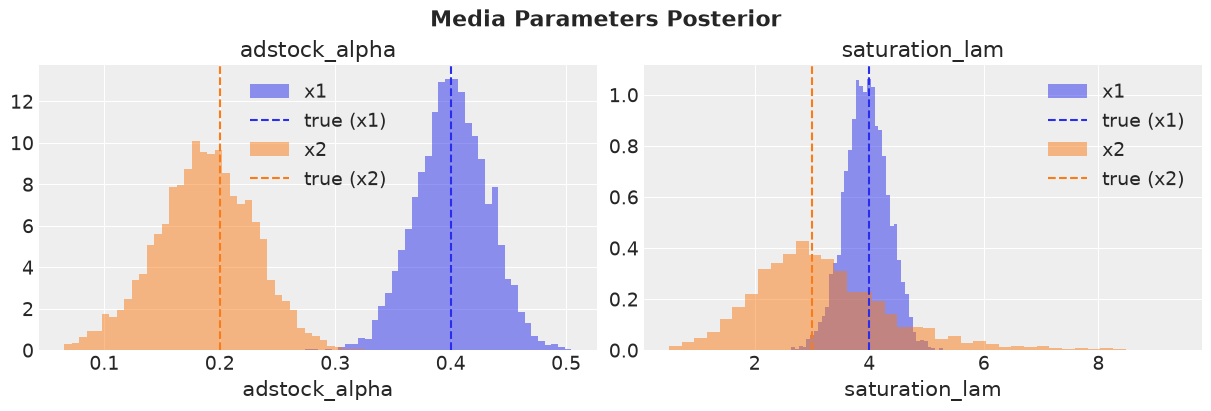

In [13]:
true_media_parameters = {
    "adstock_alpha": {"x1": alpha1, "x2": alpha2},
    "saturation_lam": {"x1": lam1, "x2": lam2},
}

fig, axes = plt.subplots(ncols=2, figsize=(12, 4), layout="constrained")
for ax, (name, truth) in zip(axes, true_media_parameters.items(), strict=True):
    for i, channel in enumerate(channels):
        samples = idata["posterior"][name].sel(channel=channel).values.ravel()
        ax.hist(samples, bins=40, density=True, alpha=0.5, color=f"C{i}", label=channel)
        ax.axvline(
            truth[channel], color=f"C{i}", linestyle="--", label=f"true ({channel})"
        )
    ax.set(title=name, xlabel=name)
    ax.legend()
fig.suptitle("Media Parameters Posterior", fontsize=16, fontweight="bold");

### Posterior Predictive Check

`sample_posterior_predictive` forward-simulates the fitted equations on whatever dataset we pass. To reproduce the in-sample fit we pass the training data with `include_last_observations=False`, since there is no earlier history to carry over (we come back to this argument below). The predictions are on the model scale, so we multiply them by the target scale to compare them with the observed sales.

Sampling: [y]


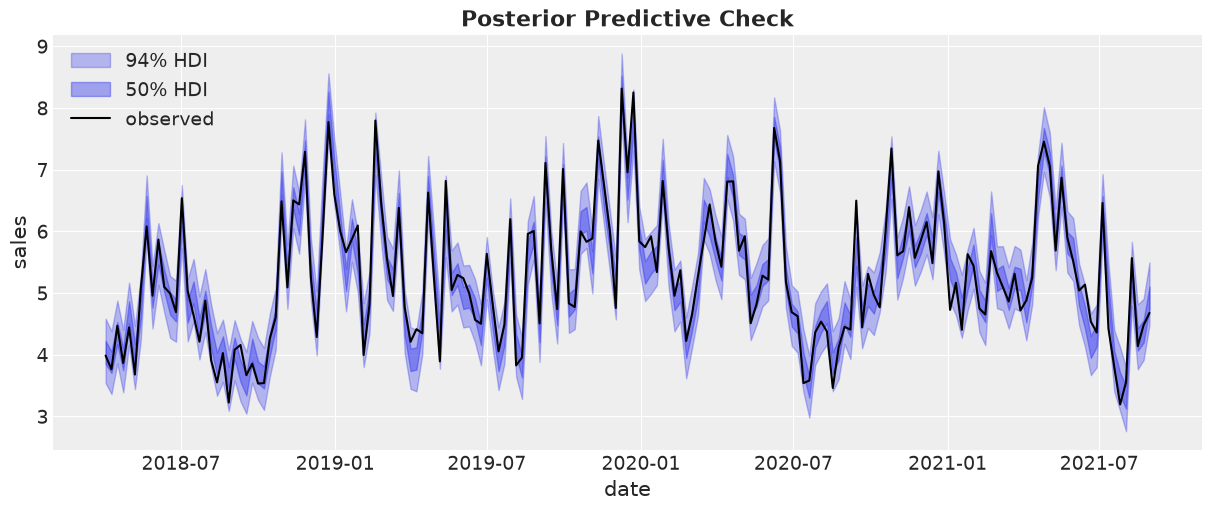

In [14]:
in_sample = mmm.sample_posterior_predictive(
    train,
    var_names=["y"],
    include_last_observations=False,
    random_seed=rng,
    progressbar=False,
)
y_original_scale = in_sample["y"] * target_scale

fig, ax = plt.subplots(figsize=(12, 5))
for i, hdi_prob in enumerate([0.94, 0.5]):
    hdi = az.hdi(y_original_scale, prob=hdi_prob)
    ax.fill_between(
        dataset["date"],
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color="C0",
        alpha=0.3 + i * 0.1,
        label=f"{hdi_prob:.0%} HDI",
    )
ax.plot(dataset["date"], dataset["sales"], color="black", label="observed")
ax.legend(loc="upper left")
ax.set(xlabel="date", ylabel="sales")
ax.set_title("Posterior Predictive Check", fontsize=16, fontweight="bold");

### Contribution Recovery

The channel contributions are ordinary posterior variables on the model scale. Multiplying them by the target scale gives their values in sales units, which we can compare with the true contributions from the data generating process:

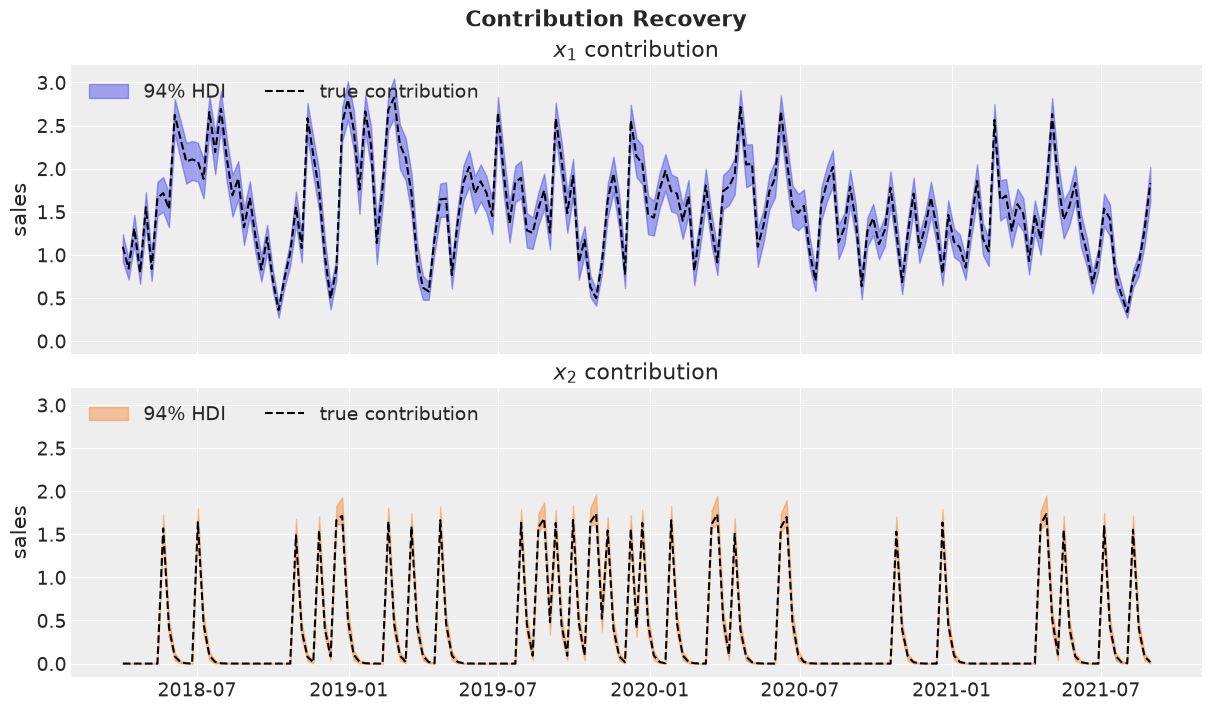

In [15]:
channel_contribution_original_scale = (
    idata["posterior"]["channel_contribution"] * target_scale
)

fig, axes = plt.subplots(
    nrows=2, figsize=(12, 7), sharex=True, sharey=True, layout="constrained"
)
for i, (ax, channel) in enumerate(zip(axes, channels, strict=True)):
    contribution = channel_contribution_original_scale.sel(channel=channel)
    hdi = az.hdi(contribution, prob=0.94)
    ax.fill_between(
        dataset["date"],
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color=f"C{i}",
        alpha=0.4,
        label="94% HDI",
    )
    ax.plot(
        df["date_week"],
        amplitude * betas[i] * df[f"{channel}_adstock_saturated"],
        color="black",
        linestyle="--",
        label="true contribution",
    )
    ax.set(title=f"$x_{i + 1}$ contribution", ylabel="sales")
    ax.legend(loc="upper left", ncol=2)
fig.suptitle("Contribution Recovery", fontsize=16, fontweight="bold");

Derived quantities such as the contribution share and the (approximate) ROAS are a couple of `xarray` operations away. Both are close to the true values of the data generating process:

In [16]:
total_contribution = channel_contribution_original_scale.sum("date")
total_spend = dataset["spend"].sum("date")

true_total_contribution = xr.DataArray(
    [
        (amplitude * beta * df[f"{channel}_adstock_saturated"]).sum()
        for beta, channel in zip(betas, channels, strict=True)
    ],
    dims="channel",
    coords={"channel": channels},
)

estimands = {
    "contribution share": (
        total_contribution / total_contribution.sum("channel"),
        true_total_contribution / true_total_contribution.sum("channel"),
    ),
    "ROAS": (total_contribution / total_spend, true_total_contribution / total_spend),
}

rows = []
for estimand, (samples, truth) in estimands.items():
    hdi = az.hdi(samples, prob=0.94)
    for channel in channels:
        rows.append(
            {
                "estimand": estimand,
                "channel": channel,
                "posterior mean": samples.sel(channel=channel).mean().item(),
                "hdi 3%": hdi.sel(channel=channel, ci_bound="lower").item(),
                "hdi 97%": hdi.sel(channel=channel, ci_bound="upper").item(),
                "true": truth.sel(channel=channel).item(),
            }
        )

pd.DataFrame(rows).set_index(["estimand", "channel"]).round(3)

posterior mean  hdi 3%  hdi 97%   true
estimand           channel                                        
contribution share x1                0.801   0.777    0.826  0.807
                   x2                0.199   0.174    0.223  0.193
ROAS               x1                4.924   4.330    5.509  4.968
                   x2                2.327   2.133    2.547  2.275

### Out-of-Sample Predictions

As in the original notebook, we forecast five weeks ahead assuming the spend of the last training week, no events, and a trend feature that keeps growing. The future dataset contains only inputs (no sales) and, because the model works on scaled spend, we divide by the **training** channel scale.

There is one policy choice to make explicit. By default, the experimental `sample_posterior_predictive` prepends the last training weeks required by the adstock (`l_max - 1 = 7` weeks), so that past spend carries over into the forecast, and drops them from the output. With `include_last_observations=False`, the forecast starts without any carryover. Note that the stable class has the opposite default.

In [17]:
last_date = dataset["date"].values[-1]

# New dates starting from last in dataset
n_new = 5
new_dates = pd.date_range(start=last_date, periods=1 + n_new, freq="W-MON")[1:]

future = xr.Dataset(
    {
        # Same channel spends as last week, on the training scale
        "spend": dataset["spend"].isel(date=-1, drop=True).expand_dims(date=new_dates)
        / channel_scale,
        # No events, and the trend feature keeps growing
        "controls": xr.DataArray(
            np.column_stack(
                [np.zeros(n_new), np.zeros(n_new), np.arange(n, n + n_new)]
            ),
            dims=("date", "control"),
            coords={"date": new_dates, "control": controls},
        ),
    }
)

forecasts = {
    "adstock out of sample": mmm.sample_posterior_predictive(
        future, var_names=["y"], random_seed=rng, progressbar=False
    ),
    "out of sample": mmm.sample_posterior_predictive(
        future,
        var_names=["y"],
        include_last_observations=False,
        random_seed=rng,
        progressbar=False,
    ),
}

Sampling: [y]


Sampling: [y]


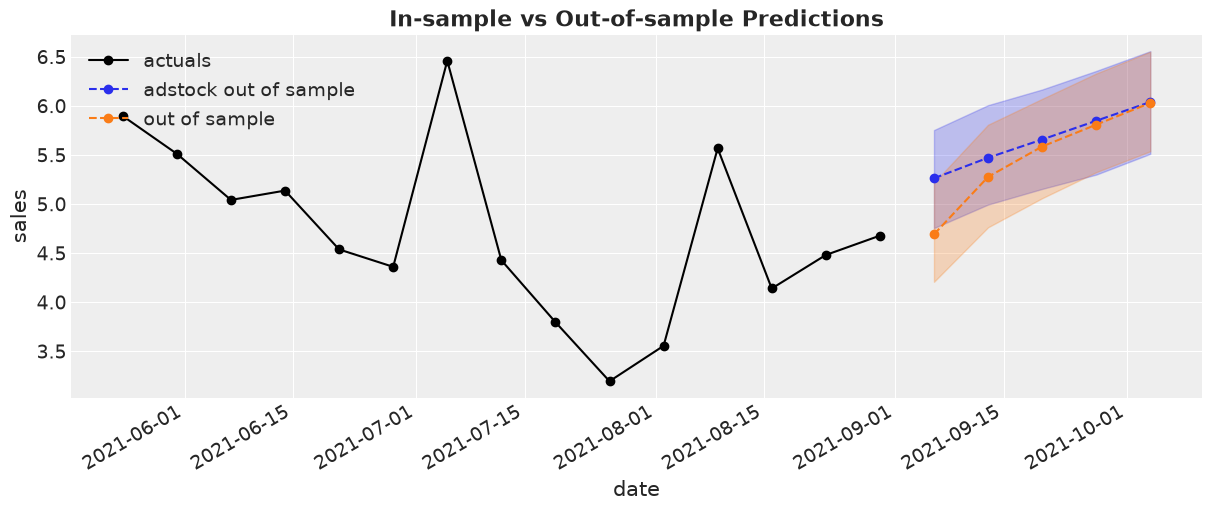

In [18]:
n_points = 15

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    dataset["date"][-n_points:],
    dataset["sales"][-n_points:],
    marker="o",
    color="black",
    label="actuals",
)
for i, (label, forecast) in enumerate(forecasts.items()):
    forecast_original_scale = forecast["y"] * target_scale
    hdi = az.hdi(forecast_original_scale, prob=0.94)
    ax.fill_between(
        new_dates,
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color=f"C{i}",
        alpha=0.25,
    )
    ax.plot(
        new_dates,
        forecast_original_scale.mean(("chain", "draw")),
        marker="o",
        linestyle="--",
        color=f"C{i}",
        label=label,
    )
ax.legend(loc="upper left")
ax.set(xlabel="date", ylabel="sales")
ax.set_title("In-sample vs Out-of-sample Predictions", fontsize=16, fontweight="bold")
fig.autofmt_xdate();

The forecast that carries over the last training spend is higher in the first weeks, and both forecasts converge once the carryover effect has faded, just as in the original notebook.

---

## Part II: The MMM Multidimensional Example

Next, we rebuild the hierarchical model of the [MMM Multidimensional Example](https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_multidimensional_example.html) notebook. The same product is sold in two markets (`geo_a` and `geo_b`), and the model borrows information across them with a different pooling strategy for each media parameter:

- saturation $\beta$ is **partially pooled** across geos, through channel-level hyperpriors;
- saturation $\lambda$ is **fully pooled**, with one value per channel shared by both geos;
- adstock $\alpha$ is **unpooled**, with one value per geo and channel.

The intercept and the seasonality vary by geo, and the likelihood is a Normal distribution truncated at zero.

### Data

The original notebook reads its simulated data from a CSV file shipped with the package. We do the same.

In [19]:
seed: int = sum(map(ord, "mmm_multidimensional"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

data_path = data_dir / "mmm_multidimensional_example.csv"

data_df = pd.read_csv(data_path, parse_dates=["date"])
data_df.head()

,date,geo,x1,x2,event_1,event_2,y
0,2022-06-06,geo_a,5527.640078,0.000000,0,0,2647.596355
1,2022-06-06,geo_b,8849.257500,8063.918386,0,0,682.406280
2,2022-06-13,geo_a,6692.655692,0.000000,0,0,5020.823907
3,2022-06-13,geo_b,9073.817994,9354.014585,0,0,3753.104897
4,2022-06-20,geo_a,7124.016733,0.000000,0,0,6184.322132


### A Labeled Dataset

In the stable class, the geos enter through `dims=("geo",)`. Here `geo` is simply one more labeled dimension of the data variables: spend is `(date, geo, channel)`, the controls are `(date, geo, control)` and sales are `(date, geo)`. Pivoting the long data frame into this layout takes one line per variable.

In [20]:
channels = ["x1", "x2"]
controls = ["event_1", "event_2"]

panel = data_df.set_index(["date", "geo"]).to_xarray()

geo_dataset = xr.Dataset(
    {
        "spend": panel[channels]
        .to_dataarray("channel")
        .transpose("date", "geo", "channel"),
        "controls": panel[controls]
        .to_dataarray("control")
        .transpose("date", "geo", "control")
        .astype(float),
        "sales": panel["y"],
    }
)

print(geo_dataset)

<xarray.Dataset> Size: 14kB
Dimensions:   (date: 159, geo: 2, channel: 2, control: 2)
Coordinates:
  * date      (date) datetime64[us] 1kB 2022-06-06 2022-06-13 ... 2025-06-16
  * geo       (geo) object 16B 'geo_a' 'geo_b'
  * channel   (channel) object 16B 'x1' 'x2'
  * control   (control) object 16B 'event_1' 'event_2'
Data variables:
    spend     (date, geo, channel) float64 5kB 5.528e+03 0.0 ... 0.0 8.091e+03
    controls  (date, geo, control) float64 5kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    sales     (date, geo) float64 3kB 2.648e+03 682.4 ... 5.618e+03 5.581e+03


### Scaling per Geo

The original notebook uses `scaling={"channel": {"method": "max", "dims": ()}, "target": {"method": "max", "dims": ()}}`, that is, a separate maximum for every geo (and channel). With labeled arrays this is again just the maximum over `date`; the result matches `mmm.get_scales_as_xarray()` in the original notebook.

In [21]:
geo_channel_scale = geo_dataset["spend"].max("date")
geo_target_scale = geo_dataset["sales"].max("date")

geo_train = geo_dataset.assign(
    spend=geo_dataset["spend"] / geo_channel_scale,
    sales=geo_dataset["sales"] / geo_target_scale,
)

print("channel scale:", geo_channel_scale.to_pandas().round(2), sep="\n")
print("target scale:", geo_target_scale.to_pandas().round(2), sep="\n")

channel scale:
channel        x1        x2
geo                        
geo_a     9318.98   9755.97
geo_b    10555.08  11760.98
target scale:
geo
geo_a    13812.08
geo_b    11002.98
Name: sales, dtype: float64


### Priors

We copy the priors of the original notebook. Notice that the three pooling strategies are expressed entirely through the `dims` of each prior: the saturation $\beta$ is indexed by `(channel, geo)` but its hyperpriors only by `channel`, $\lambda$ is indexed by `channel` only, and $\alpha$ by `(geo, channel)`. The experimental API keeps every declared `dims` exactly, so this is all it needs to know.

In [22]:
beta_prior = LogNormalPrior(
    mean=Prior("Gamma", mu=0.25, sigma=0.10, dims="channel"),
    std=Prior("Exponential", scale=0.10, dims="channel"),
    dims=("channel", "geo"),
    centered=False,
)

lam_prior = Prior("Gamma", mu=0.5, sigma=0.25, dims="channel")

alpha_prior = Prior("Beta", alpha=2, beta=5, dims=("geo", "channel"))

intercept_prior = Prior("Gamma", mu=0.5, sigma=0.25, dims="geo")

gamma_control_prior = Prior("Normal", mu=0, sigma=0.5, dims="control")

gamma_fourier_prior = LaplacePrior(
    mu=0,
    b=Prior("HalfNormal", sigma=0.2),
    dims=("geo", "fourier_mode"),
    centered=False,
)

likelihood = Prior("TruncatedNormal", lower=0, sigma=Prior("HalfNormal", sigma=1.5))

### Model Specification

The model equation has the same structure as in Part I; we only swap the priors and the likelihood. The `geo` dimension flows through every term by name:

- the media transformations run along `date` on spend `(date, geo, channel)`, and each media parameter broadcasts over the dimensions it declares;
- the intercept has one value per geo;
- `Dot` contracts the controls `(date, geo, control)` with `gamma_control` `(control)` into `(date, geo)`;
- the seasonality coefficients are `(geo, fourier_mode)`, so each geo gets its own seasonal pattern.

The output of an `Equation` takes the dimensions of its observations, `(date, geo)`, so the likelihood recipe does not need a `dims` argument.

In [23]:
geo_channel_contribution = (
    Data("spend")
    >> GeometricAdstock(l_max=8, priors={"alpha": alpha_prior})
    >> LogisticSaturation(priors={"beta": beta_prior, "lam": lam_prior})
).named("channel_contribution")

geo_mu = (
    Intercept("intercept_contribution", prior=intercept_prior)
    + geo_channel_contribution.sum("channel")
    + Dot(var_name="controls", name="gamma_control", prior=gamma_control_prior)
    + Seasonality(
        YearlyFourier(
            n_order=2,
            prefix="fourier_mode",
            variable_name="gamma_fourier",
            prior=gamma_fourier_prior,
        )
    )
)

geo_sales = Equation(name="y", observed="sales", mu=geo_mu, likelihood=likelihood)

geo_mmm = MMM(geo_sales)
geo_mmm.build_model(geo_train)

model_table(geo_mmm.model)

                     Variable  Expression                                          Dimensions                      
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                   controls =  Data                                                date[159] × geo[2] × control[2] 
       _experimental_data_0 =  Data                                                date[159] × geo[2] × channel[2] 
  _fourier_mode_dayofperiod =  Data                                                date[159]                       
       _experimental_data_1 =  Data                                                date[159] × geo[2]              
                                                                                                                   
     intercept_contribution ~  Gamma(<constant>, <constant>)                       geo[2]                          
              adstock_alpha ~  Beta(2, 5)                                          geo[2] × channel[2]             
             saturation_lam ~  Gamma(<constant>, <constant>)                       channel[2]                      
       saturation_beta_mean ~  Gamma(<constant>, <constant>)                       channel[2]                      
        saturation_beta_std ~  Exponential(0.1)                                    channel[2]                      
 saturation_beta_log_offset ~  Normal(0, 1)                                        channel[2] × geo[2]             
              gamma_control ~  Normal(0, 0.5)                                      control[2]                      
            gamma_fourier_b ~  HalfNormal(0, 0.2)                                                                  
        gamma_fourier_sigma ~  Exponential(f(gamma_fourier_b))                                                     
       gamma_fourier_offset ~  Normal(0, 1)                                        geo[2] × fourier_mode[4]        
                    y_sigma ~  HalfNormal(0, 1.5)                                                                  
                                                                                   Parameter count = 29            
                                                                                                                   
            saturation_beta =  f(saturation_beta_log_offset,                       channel[2] × geo[2]             
                               saturation_beta_mean, saturation_beta_std)                                          
       channel_contribution =  f(saturation_beta_log_offset, saturation_lam,       date[159] × geo[2] × channel[2] 
                               saturation_beta_mean, saturation_beta_std,                                          
                               adstock_alpha)                                                                      
              gamma_fourier =  f(gamma_fourier_offset, gamma_fourier_sigma)        geo[2] × fourier_mode[4]        
                                                                                                                   
                          y ~  Unknown(TruncatedNormal(f(gamma_control,            date[159] × geo[2]              
                               intercept_contribution, gamma_fourier_offset,                                       
                               gamma_fourier_sigma, saturation_beta_log_offset,                                    
                               saturation_lam, saturation_beta_mean,                                               
                               saturation_beta_std, adstock_alpha), y_sigma, 0,                                    
                               inf))

The model automatically vectorizes over the geos and creates the expected hierarchies 🚀. The non-centered parameterizations of `LogNormalPrior` and `LaplacePrior` add their auxiliary variables (`saturation_beta_log_offset`, `gamma_fourier_offset`, ...) just as they do in the stable class.

### Is It Really the Same Model?

We repeat the log-density check against the stable `MMM`, configured exactly as in the original notebook.

In [24]:
stable_geo_mmm = StableMMM(
    date_column="date",
    target_column="y",
    channel_columns=["x1", "x2"],
    control_columns=["event_1", "event_2"],
    dims=("geo",),
    scaling={
        "channel": {"method": "max", "dims": ()},
        "target": {"method": "max", "dims": ()},
    },
    adstock=GeometricAdstock(priors={"alpha": alpha_prior}, l_max=8),
    saturation=LogisticSaturation(priors={"beta": beta_prior, "lam": lam_prior}),
    yearly_seasonality=2,
    model_config={
        "intercept": Prior("Gamma", mu=0.5, sigma=0.25, dims="geo"),
        "gamma_control": Prior("Normal", mu=0, sigma=0.5, dims="control"),
        "gamma_fourier": LaplacePrior(
            mu=0,
            b=Prior("HalfNormal", sigma=0.2),
            dims=("geo", "fourier_mode"),
            centered=False,
        ),
        "likelihood": Prior(
            "TruncatedNormal",
            lower=0,
            sigma=Prior("HalfNormal", sigma=1.5),
            dims=("date", "geo"),
        ),
    },
)
stable_geo_mmm.build_model(X=data_df.drop(columns=["y"]), y=data_df["y"])

compare_log_densities(geo_mmm.model, stable_geo_mmm.model)

,experimental,stable
0,-256.397422,-256.397422
1,-398.503241,-398.503241
2,-377.183643,-377.183643
3,-278.988190,-278.988190
4,-407.537794,-407.537794


Identical again, including the special priors and the truncated likelihood.

### Model Fitting

We fit the model with the sampler settings of the original notebook.

In [25]:
geo_idata = geo_mmm.fit(
    geo_train,
    chains=4,
    target_accept=0.95,
    random_seed=rng,
    progressbar=False,
)

print("Divergences:", geo_idata["sample_stats"]["diverging"].sum().item())

NUTS[nutpie]: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta_mean, saturation_beta_std, saturation_beta_log_offset, gamma_control, gamma_fourier_b, gamma_fourier_sigma, gamma_fourier_offset, y_sigma]


Divergences: 0


No divergences again, and the summary is in line with the one reported in the original notebook:

In [26]:
az.summary(
    geo_idata,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_beta_mean",
        "saturation_beta_std",
        "saturation_lam",
        "y_sigma",
    ],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"adstock_alpha[geo_a, x1]",0.295,0.163,0.068,0.59,5670,2575,1.00,0.0021,0.0014
"adstock_alpha[geo_a, x2]",0.306,0.168,0.072,0.61,5940,2716,1.00,0.0021,0.0013
"adstock_alpha[geo_b, x1]",0.26,0.147,0.06,0.53,6219,2901,1.00,0.0018,0.0013
"adstock_alpha[geo_b, x2]",0.277,0.161,0.058,0.57,5559,2364,1.00,0.002,0.0015
gamma_control[event_1],0.305,0.087,0.17,0.44,5440,2996,1.00,0.0012,0.00089
gamma_control[event_2],-0.1,0.094,-0.25,0.044,6819,2991,1.00,0.0012,0.00084
"gamma_fourier[geo_a, sin_1]",-0.35,0.035,-0.41,-0.3,3572,3371,1.00,0.00059,0.00043
"gamma_fourier[geo_a, sin_2]",-0.0277,0.0283,-0.075,0.016,5211,3481,1.00,0.00039,0.00027
"gamma_fourier[geo_a, cos_1]",-0.285,0.0333,-0.34,-0.23,3810,3391,1.00,0.00054,0.0004
"gamma_fourier[geo_a, cos_2]",0.0038,0.0275,-0.04,0.047,4998,3130,1.00,0.00039,0.00028


### Posterior Predictive Check

As before, we simulate the in-sample predictions and multiply them by the target scale, which now has one value per geo.

Sampling: [y]


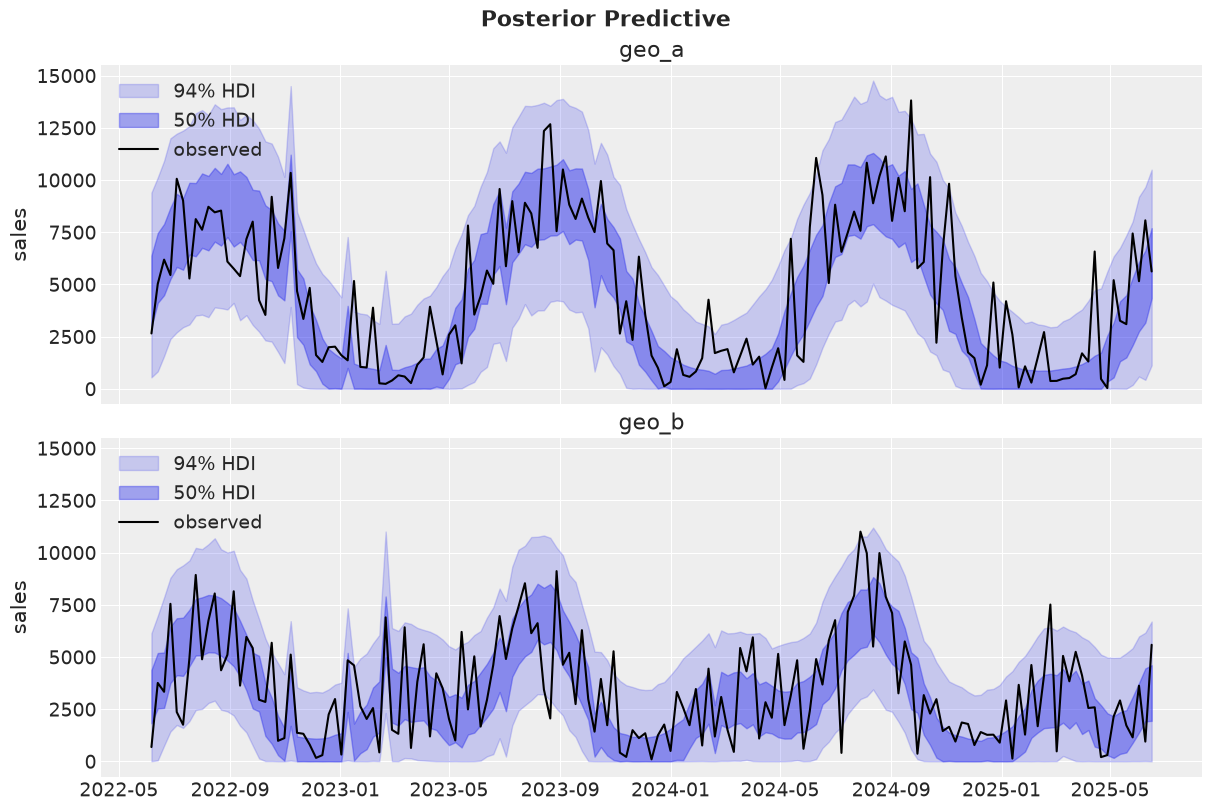

In [27]:
geo_in_sample = geo_mmm.sample_posterior_predictive(
    geo_train,
    var_names=["y"],
    include_last_observations=False,
    random_seed=rng,
    progressbar=False,
)
geo_y_original_scale = geo_in_sample["y"] * geo_target_scale

fig, axes = plt.subplots(
    nrows=2, figsize=(12, 8), sharex=True, sharey=True, layout="constrained"
)
for ax, geo in zip(axes, geo_dataset["geo"].values, strict=True):
    for i, hdi_prob in enumerate([0.94, 0.5]):
        hdi = az.hdi(geo_y_original_scale.sel(geo=geo), prob=hdi_prob)
        ax.fill_between(
            geo_dataset["date"],
            hdi.sel(ci_bound="lower"),
            hdi.sel(ci_bound="upper"),
            color="C0",
            alpha=0.2 + i * 0.2,
            label=f"{hdi_prob:.0%} HDI",
        )
    ax.plot(
        geo_dataset["date"],
        geo_dataset["sales"].sel(geo=geo),
        color="black",
        label="observed",
    )
    ax.legend(loc="upper left")
    ax.set(title=geo, ylabel="sales")
fig.suptitle("Posterior Predictive", fontsize=16, fontweight="bold");

As discussed in the original notebook, there is a lot of white noise in the sales process that we cannot predict, but the main movements are captured by the seasonality and the media components.

### Parameter Recovery

We compare the posteriors of the media parameters with the true values used to simulate the data, which the original notebook loads from a NetCDF file. As explained there, we do not expect every posterior mean to line up with the true value in such small and noisy data, but we do expect the bulk of each posterior to cover it.

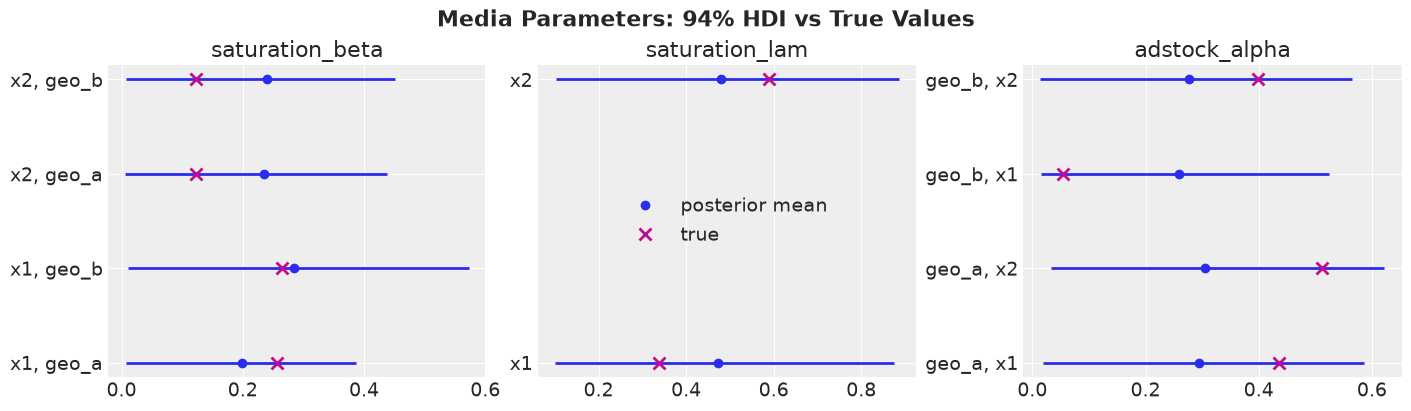

In [28]:
data_path = data_dir / "mmm_multidimensional_example_true_parameters.nc"
true_parameters = xr.open_dataset(data_path)

fig, axes = plt.subplots(ncols=3, figsize=(14, 4), layout="constrained")
for ax, name in zip(
    axes, ["saturation_beta", "saturation_lam", "adstock_alpha"], strict=True
):
    posterior = geo_idata["posterior"][name]
    dims = [dim for dim in posterior.dims if dim not in ("chain", "draw")]
    hdi = az.hdi(posterior, prob=0.94)
    summary = pd.DataFrame(
        {
            "mean": posterior.mean(("chain", "draw")).transpose(*dims).to_series(),
            "lower": hdi.sel(ci_bound="lower").transpose(*dims).to_series(),
            "upper": hdi.sel(ci_bound="upper").transpose(*dims).to_series(),
            "true": true_parameters[name].transpose(*dims).to_series(),
        }
    )
    positions = np.arange(len(summary))
    ax.hlines(positions, summary["lower"], summary["upper"], color="C0", lw=2)
    ax.plot(summary["mean"], positions, "o", color="C0", label="posterior mean")
    ax.plot(summary["true"], positions, "x", color="C3", ms=9, mew=2, label="true")
    ax.set_yticks(
        positions,
        [
            ", ".join(label) if isinstance(label, tuple) else label
            for label in summary.index
        ],
    )
    ax.set(title=name)
axes[1].legend(loc="center")
fig.suptitle(
    "Media Parameters: 94% HDI vs True Values", fontsize=16, fontweight="bold"
);

The true values fall within the posterior bulk, in line with the original notebook.

### Out-of-Sample Predictions

We forecast seven weeks ahead with the spend of the last training week in each geo and no events, carrying over the adstock from the training period (the default). Again, the future spend is divided by the training scales, and the forecast is multiplied back by the per-geo target scale.

In [29]:
geo_last_date = geo_dataset["date"].values[-1]

# New dates starting from last in dataset
n_new = 7
geo_new_dates = pd.date_range(start=geo_last_date, periods=1 + n_new, freq="W-MON")[1:]

geo_future = xr.Dataset(
    {
        # Same channel spends as last week, per geo, on the training scale
        "spend": geo_dataset["spend"]
        .isel(date=-1, drop=True)
        .expand_dims(date=geo_new_dates)
        / geo_channel_scale,
        # No events
        "controls": xr.zeros_like(
            geo_dataset["controls"].isel(date=-1, drop=True)
        ).expand_dims(date=geo_new_dates),
    }
)

geo_forecast = geo_mmm.sample_posterior_predictive(
    geo_future, var_names=["y"], random_seed=rng, progressbar=False
)
geo_forecast_original_scale = geo_forecast["y"] * geo_target_scale

Sampling: [y]


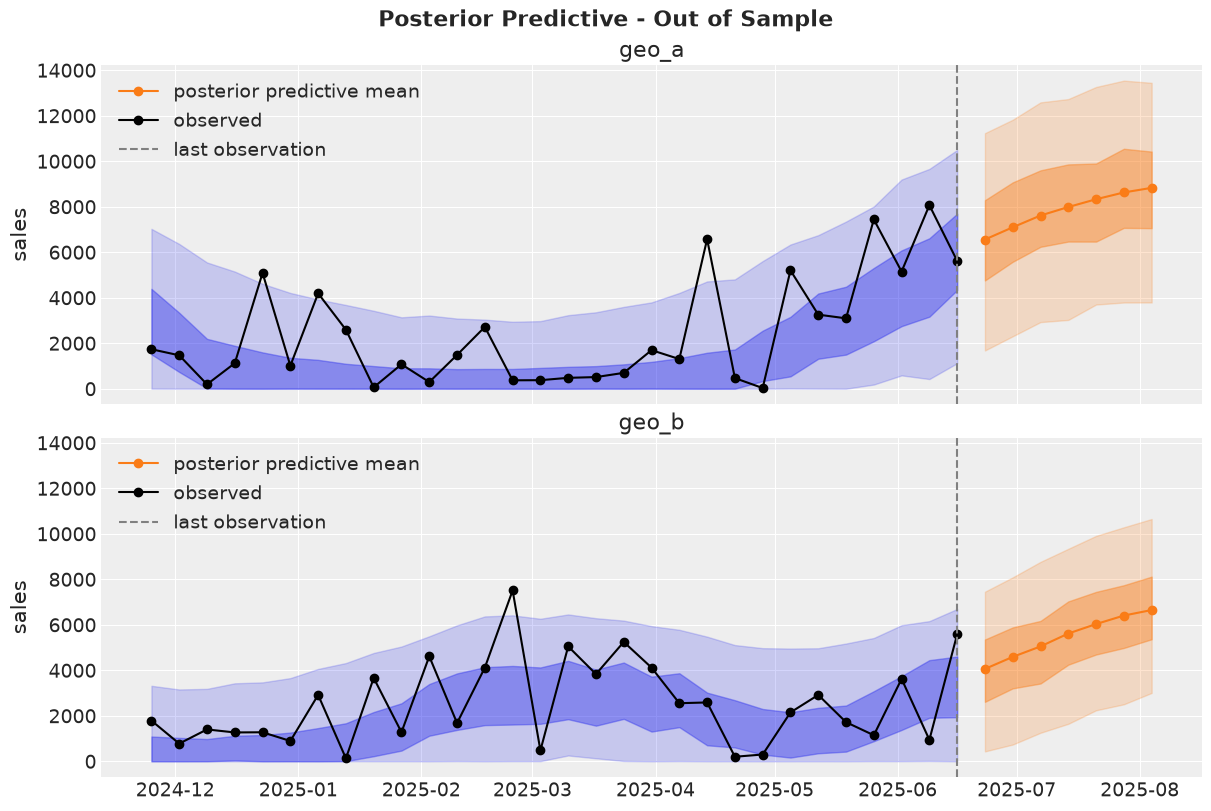

In [30]:
n_train_to_plot = 30

fig, axes = plt.subplots(
    nrows=2, figsize=(12, 8), sharex=True, sharey=True, layout="constrained"
)
for ax, geo in zip(axes, geo_dataset["geo"].values, strict=True):
    in_sample_tail = geo_y_original_scale.sel(geo=geo).isel(
        date=slice(-n_train_to_plot, None)
    )
    for i, hdi_prob in enumerate([0.94, 0.5]):
        for color, predictions in (
            ("C0", in_sample_tail),
            ("C1", geo_forecast_original_scale.sel(geo=geo)),
        ):
            hdi = az.hdi(predictions, prob=hdi_prob)
            ax.fill_between(
                predictions["date"],
                hdi.sel(ci_bound="lower"),
                hdi.sel(ci_bound="upper"),
                color=color,
                alpha=0.2 + i * 0.2,
            )
    ax.plot(
        geo_new_dates,
        geo_forecast_original_scale.sel(geo=geo).mean(("chain", "draw")),
        marker="o",
        color="C1",
        label="posterior predictive mean",
    )
    ax.plot(
        geo_dataset["date"][-n_train_to_plot:],
        geo_dataset["sales"].sel(geo=geo)[-n_train_to_plot:],
        marker="o",
        color="black",
        label="observed",
    )
    ax.axvline(x=geo_last_date, color="gray", linestyle="--", label="last observation")
    ax.legend(loc="upper left")
    ax.set(title=geo, ylabel="sales")
fig.suptitle("Posterior Predictive - Out of Sample", fontsize=16, fontweight="bold");

---

## Summary

We rebuilt both reference models with the experimental API and verified that each one has exactly the same joint log density as its stable counterpart. The translation came down to three explicit steps that the stable class otherwise takes for us:

1. **Scaling.** We divide spend and sales by their training maxima ourselves, and reuse those scales to prepare forecast inputs and to report results in the original units.
2. **Dimensions.** Every prior declares all of its dimensions, including `channel` for the media parameters. Pooling across geos is then nothing more than the choice of dims.
3. **Reductions and likelihood.** The sum over channels is written out, and an `Equation` binds the likelihood to a named observation variable.

The stable `MMM` still offers a lot on top of the model itself, such as the plot suite, budget optimization, sensitivity analysis, and saving and loading models, none of which is part of the experimental API yet. What the explicit graph buys us instead is flexibility: because a model is a set of observed equations built from shared terms, the same building blocks also describe models beyond the fixed structure of the stable class, for example several outcomes that share the same media parameters, or calibration data written as just another observed equation.

In [31]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor,nutpie

Last updated: Mon, 28 Sep 2026

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pytensor      : 3.3.2
nutpie        : 0.16.11

arviz         : 1.2.0
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 3.0.5
pymc_extras   : 0.15.1
pymc_marketing: 1.1.0
xarray        : 2026.4.0

Watermark: 2.6.0

